## Data Visualisation with Python

In [1]:
# Import the necessary libraries
# Import the necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

## Step Process
1. Load Data
2. Inspect Data
3. Clean Data (if needed)
4. Explore + Visualise Data
5. Derive insights from Data Exploration/Visualisation

### Example 1: Forbes 2022 Data

#### 1. Load Data

In [3]:
forbes = pd.read_csv('forbes_2022.csv')
forbes

,Unnamed: 0,rank,name,networth,age,country,source,industry
0,0,1,Elon Musk,$219 B,50,United States,"Tesla, SpaceX",Automotive
1,1,2,Jeff Bezos,$171 B,58,United States,Amazon,Technology
2,2,3,Bernard Arnault & family,$158 B,73,France,LVMH,Fashion & Retail
3,3,4,Bill Gates,$129 B,66,United States,Microsoft,Technology
4,4,5,Warren Buffett,$118 B,91,United States,Berkshire Hathaway,Finance & Investments
...,...,...,...,...,...,...,...,...
2595,2595,2578,Jorge Gallardo Ballart,$1 B,80,Spain,pharmaceuticals,Healthcare
2596,2596,2578,Nari Genomal,$1 B,82,Philippines,apparel,Fashion & Retail
2597,2597,2578,Ramesh Genomal,$1 B,71,Philippines,apparel,Fashion & Retail
2598,2598,2578,Sunder Genomal,$1 B,68,Philippines,garments,Fashion & Retail


#### 2. Inspect Data

In [5]:
#If True, means duplicate
forbes.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
2595    False
2596    False
2597    False
2598    False
2599    False
Length: 2600, dtype: bool

In [6]:
forbes.duplicated().sum()

0

In [7]:
forbes.isnull().sum()

Unnamed: 0    0
rank          0
name          0
networth      0
age           0
country       0
source        0
industry      0
dtype: int64

In [6]:
#if has null value
#forbes.dropna()

In [8]:
#Check data type, see if the type makes sense
forbes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  2600 non-null   int64 
 1   rank        2600 non-null   int64 
 2   name        2600 non-null   object
 3   networth    2600 non-null   object
 4   age         2600 non-null   int64 
 5   country     2600 non-null   object
 6   source      2600 non-null   object
 7   industry    2600 non-null   object
dtypes: int64(3), object(5)
memory usage: 162.6+ KB


#### 3. Clean Data

In [11]:
#Dtype is object indicates a generic type that can represent any Python object, including string, numbers..
#for a dataframe in pandas, it usually represents string

#Replace the $ and B with empty string
#str.replace(oldvalue,newvalue,count)
forbes['networth'] = forbes['networth'].str.replace('$', '')
forbes['networth'] = forbes['networth'].str.replace('B', '')

#Change type to numeric
forbes['networth'] = pd.to_numeric(forbes['networth'])

AttributeError: Can only use .str accessor with string values!

#### 4. Explore Data

In [12]:
forbes.head()

,Unnamed: 0,rank,name,networth,age,country,source,industry
0,0,1,Elon Musk,219.0,50,United States,"Tesla, SpaceX",Automotive
1,1,2,Jeff Bezos,171.0,58,United States,Amazon,Technology
2,2,3,Bernard Arnault & family,158.0,73,France,LVMH,Fashion & Retail
3,3,4,Bill Gates,129.0,66,United States,Microsoft,Technology
4,4,5,Warren Buffett,118.0,91,United States,Berkshire Hathaway,Finance & Investments


In [16]:
# Finding the industry with the highest number of billionaires
#value_counts() counts the frequency of unique values in specific columns of a dataframe
forbes['industry'].value_counts().sort_index()

Automotive                      69
Construction & Engineering      43
Diversified                    178
Energy                          93
Fashion & Retail               246
Finance & Investments          386
Food & Beverage                201
Gambling & Casinos              23
Healthcare                     212
Logistics                       35
Manufacturing                  322
Media & Entertainment           95
Metals & Mining                 67
Real Estate                    189
Service                         51
Sports                          26
Technology                     329
Telecom                         35
Name: industry, dtype: int64

In [15]:
# To display the top 5 industries with the most number of billionaires
forbes['industry'].value_counts()[:5]

Finance & Investments     386
Technology                329
Manufacturing             322
Fashion & Retail          246
Healthcare                212
Name: industry, dtype: int64

<Axes: >

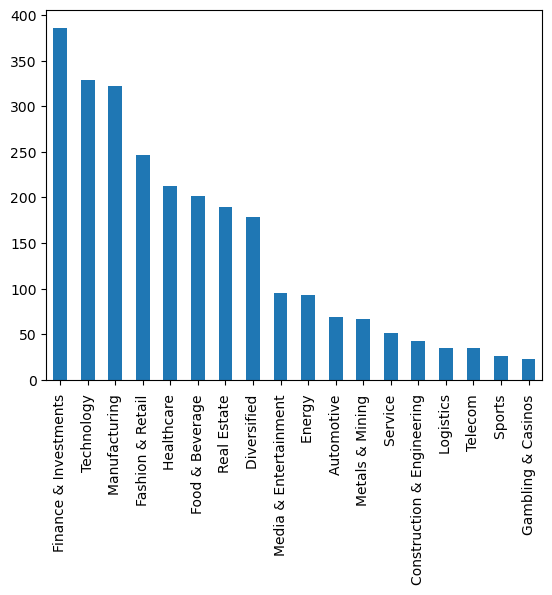

In [18]:
# show the number of billionaires in each industry with bar chart
forbes['industry'].value_counts().plot( kind = 'bar')

<Axes: >

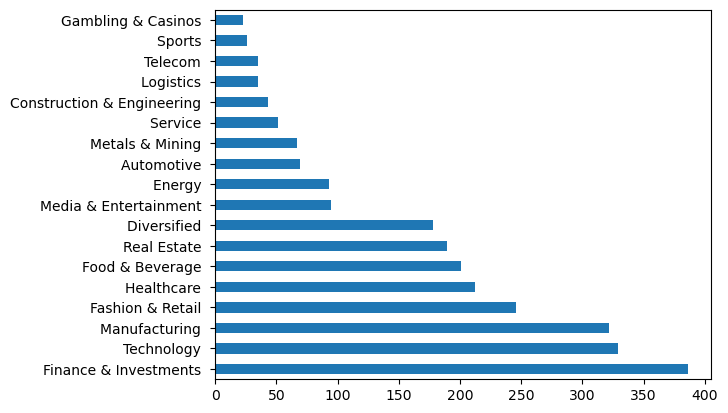

In [19]:
#Horizontal bar
forbes['industry'].value_counts().plot( kind = 'barh')

<Axes: >

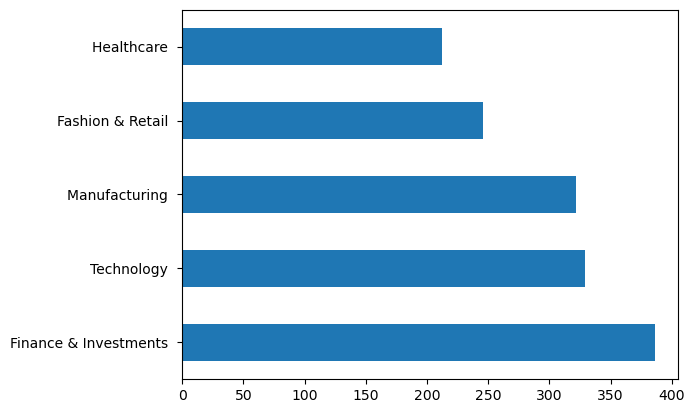

In [21]:
# Finding the country with the highest number of billionaires
forbes['industry'].value_counts()[:5].plot( kind = 'barh')

<Axes: >

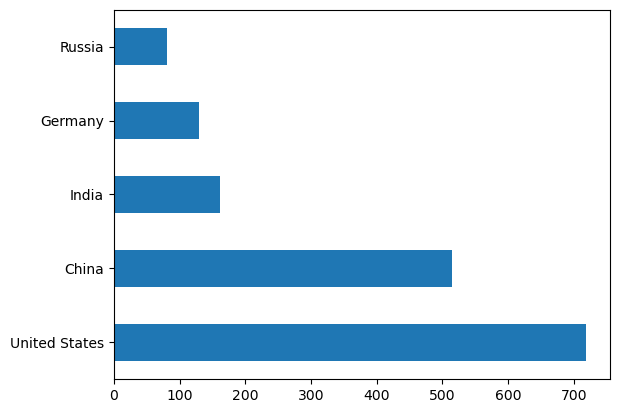

In [22]:
#display the top 3 countries with the most billionaries
forbes['country'].value_counts()[0:5].plot(kind='barh')

In [23]:
# Find the billionaires with networth more than 60 billion dollars
#To filter a dataframe base on a condition, we need to use dataframe[condition] where the condition is a boolean expression
#condition=forbes['networth']>=60,True-more than or equal 60, False-less than 60
forbes['networth'] >= 60
# OR


0        True
1        True
2        True
3        True
4        True
        ...  
2595    False
2596    False
2597    False
2598    False
2599    False
Name: networth, Length: 2600, dtype: bool

In [28]:
#find the top 5 youngest billionaires
forbes.sort_values(by = ['age'])[:5]

,Unnamed: 0,rank,name,networth,age,country,source,industry
1311,1311,1292,Kevin David Lehmann,2.4,19,Germany,drugstores,Fashion & Retail
2062,2062,1929,Wang Zelong,1.5,25,China,chemicals,Metals & Mining
1975,1975,1929,Pedro Franceschi,1.5,25,Brazil,fintech,Finance & Investments
2190,2190,2190,Alexandra Andresen,1.3,25,Norway,investments,Diversified
1961,1961,1929,Henrique Dubugras,1.5,26,Brazil,fintech,Finance & Investments


In [ ]:
# rearrange the dataframe by ascending or descending order of specific column
#parameter of sort_values: by-specify label to sort by, axis:0 or 1, ascending:True or False


In [25]:
# Finding the top 5 youngest people who have networth of more than 50 billion
forbes_more_50 = forbes[forbes['networth'] >= 50]
forbes_more_50.sort_values(by = ['age'][0:5])

#Or

,Unnamed: 0,rank,name,networth,age,country,source,industry
14,14,15,Mark Zuckerberg,67.3,37,United States,Facebook,Technology
24,24,25,Zhang Yiming,50.0,38,China,TikTok,Media & Entertainment
19,19,19,Changpeng Zhao,65.0,44,Canada,cryptocurrency exchange,Finance & Investments
6,6,7,Sergey Brin,107.0,48,United States,Google,Technology
5,5,6,Larry Page,111.0,49,United States,Google,Technology
0,0,1,Elon Musk,219.0,50,United States,"Tesla, SpaceX",Automotive
23,23,24,Michael Dell,55.1,57,United States,Dell computers,Technology
1,1,2,Jeff Bezos,171.0,58,United States,Amazon,Technology
21,21,21,Julia Koch & family,60.0,59,United States,Koch Industries,Diversified
10,10,11,Gautam Adani & family,90.0,59,India,"infrastructure, commodities",Diversified


(array([2.44e+03, 9.20e+01, 3.00e+01, 9.00e+00, 6.00e+00, 8.00e+00,
        2.00e+00, 2.00e+00, 3.00e+00, 2.00e+00, 2.00e+00, 1.00e+00,
        0.00e+00, 0.00e+00, 1.00e+00, 1.00e+00, 0.00e+00, 0.00e+00,
        0.00e+00, 1.00e+00]),
 array([  1. ,  11.9,  22.8,  33.7,  44.6,  55.5,  66.4,  77.3,  88.2,
         99.1, 110. , 120.9, 131.8, 142.7, 153.6, 164.5, 175.4, 186.3,
        197.2, 208.1, 219. ]),
 <BarContainer object of 20 artists>)

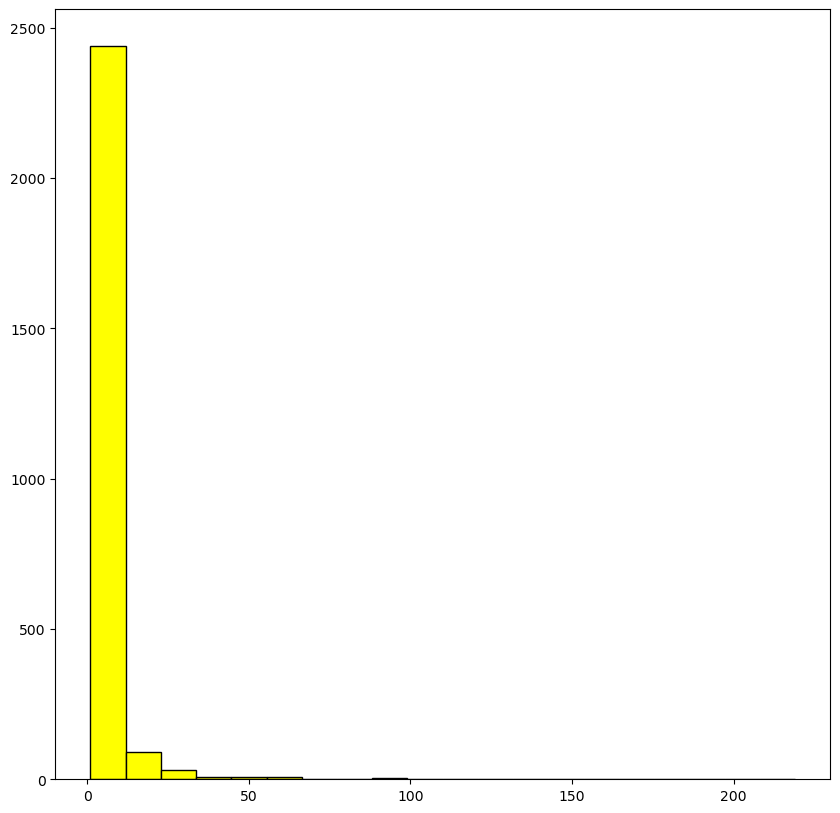

In [29]:
ig, ax = plt.subplots(figsize=(10,10))
ax.hist(forbes.networth, bins=20, edgecolor='black', color = "yellow")

In [ ]:
#Using the method we used previously

# the higher the bin, the closer it is to the distribution plot which will be explained later
 #Notice the graphs are still similar to each other

##### Data Visualisation - Distribution Plot
- Shows how a variable in your data is distributed

# Distribution Plot

> parameter:
* data: dataframe name
* x,y,hue: variable name
* kind:{“hist”, “kde”, “ecdf”} hist by default, same as histplot(), kdeplot(), ecdfplot(univariate data only)
* color, palette, height...

1.   kernel density estimation:KDE represents the data using a continuous probability density curve, more smooth
2.    empirical cumulative distribution function: represents the proportion or counts of observations


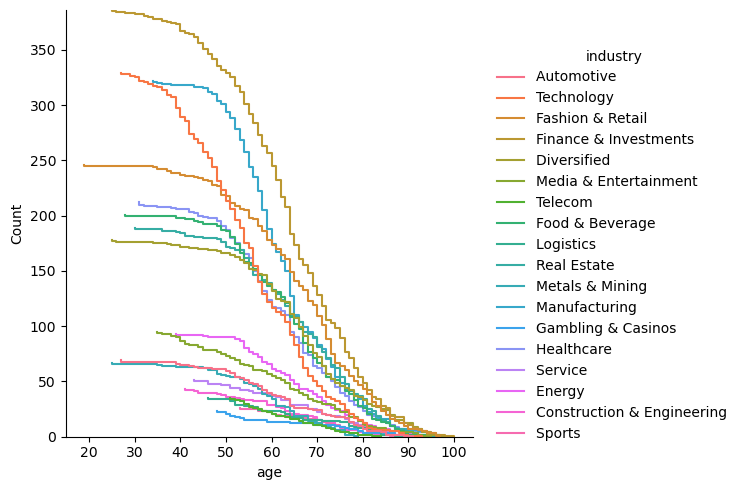

In [40]:
#Distribution plot of the age variable
#sns.displot(x="age", data=forbes)
#plt.show()

sns.displot(x='age', hue ='industry', kind ='ecdf', data=forbes, stat= 'count', complementary=True)
plt.show()

Observation from dataset:
1. Most saturated industry/best industry (Finance & Investments)
2. Country with the most opportunity (US) - may be too saturated
3. Who to learn from (THose that really made it)
4. Probable age for someone to get really rich (50-70 years old)

### Example 2: Annual Sales 2018 Data

#### 1. Load Data

In [ ]:
2018 = pd.read_csv('2018_annual.csv')


In [ ]:
#parameter of drop: label, axis: 1 for column, 0 for index, default 0
#Better to name it with another variable so that you can keep the original dataset under the variable 'data'


#### 2. Inspect Data

#### 3. Clean Data

In [ ]:
#Convert 'Order Date' column into datetime type


#### 4. Explore Data

In [ ]:
# series.dt can be used to access the values of the series as datetimelike and return several properties
#dt.year will return year, dt.weekday will return the day of week

In [ ]:
#Which month had the best sales?

In [ ]:
#creat a new column called Sale

In [ ]:
#here Month is index label not variable


###### ***HOW THE PREVIOUS CODE LOOK LIKE (STEP BY STEP)***

In [ ]:
#How it looks like, ingore the rest of the table except for Sales

In [ ]:
 #Rearranging the sales amount in ascending amount

In [ ]:
 #Get only the 'Sales' column

#### Data Visualisation

In [ ]:
#Data Visualisation


# what is def
  * def function name(argument):
  * statement
  * return expression

In [42]:
#example


In [ ]:
#Finding the orders where the production city is the same as the city in the purchase address


  #address patteern is street,city,postal code
  #split() split a string into a list of substrings, the parameter is separator




 #you can apply a function you defined earlier in the dataset, the parameter: func


In [ ]:
#Group data by cities


In [ ]:
#Which city makes the best sales across all 12 months



In [ ]:
#display information of gross sales in every city for 1st 3 months
#loc, accedd a group of rows based on positional index
# group_data.loc[3,:] means select a specific row based on 3 and all its columns
#why use []? In pandas, using [] to access elements form df, () for function calls


In [ ]:
# Can query individual cities (Example: Atlanta)


In [ ]:
#query each month sales for specific city


# create a line chart to show how the sale change in each city for 12 months?

In [ ]:
# Get a list of cities
 #so there will be no duplicate


In [ ]:

  #Get the city's 12 months of sales


  #Plot line plot for this city
  #parameter: only y is required
